<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/69/Airbnb_Logo_B%C3%A9lo.svg/1280px-Airbnb_Logo_B%C3%A9lo.svg.png" width="160">
</p>

---

## Table of Contents
1. [Project Overview](#1-project-overview)
2. [Setup & Imports](#2-setup--imports)
3. [Data Loading & Initial Inspection](#3-data-loading--initial-inspection)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis)
5. [Data Cleaning](#5-data-cleaning)
6. [Feature Engineering & Correlation Analysis](#6-feature-engineering--correlation-analysis)
7. [Data Preparation for Training](#7-data-preparation-for-training)
8. [Model Comparison](#8-model-comparison)
9. [Best Model Selection & Hyperparameter Tuning](#9-best-model-selection--hyperparameter-tuning)
10. [Conclusion](#10-conclusion)


---
## 1. Project Overview

### Business Context
New York City is one of Airbnb's most competitive markets globally. For a first-time host, pricing a listing correctly is the difference between a fully booked calendar and months of vacancy. For a traveller, understanding the market prevents overpaying.

### Problem Statement
The short-term rental market in NYC is characterised by high price volatility driven by location, room type, availability and host behaviour. Raw Airbnb data has a lot of problems like listings with zero prices, unusually high prices, and missing review dates. It makes hard to get an accurate view of the market. This project fixes those issues, finds the useful patterns in the data, and builds a model to predict nightly prices.

### Research Questions
1. How effectively can machine learning algorithms (Linear Regression, Ridge, Random Forest, XGBoost, LightGBM) predict Airbnb prices given high outlier volume and low feature correlation?
2. To what extent do **location** and **room type** dominate the pricing structure compared to other quantitative attributes?

### Pipeline at a Glance
| Stage | Description |
|---|---|
| **EDA** | Understand distributions, identify anomalies, visualise key relationships |
| **Cleaning** | Handle nulls, remove duplicates, cap price outliers |
| **Feature Engineering** | `dist_to_center` (Haversine), `neighborhood_tier`, `has_reviews` |
| **Correlation Analysis** | Heatmap, pairplot, feature importance before training |
| **Modelling** | 5 regressors compared; best model selected by MAE / RMSE / R^2 |
| **Tuning** | GridSearchCV on the winning model |
| **Conclusion** | Insights, limitations, next steps |

### Dataset
- Source: [NYC Airbnb Open Data 2019](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) via Kaggle
- Rows: ~48,895 listings  |  Columns: 16 features


---
## 2. Setup & Imports

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from time import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

AIRBNB_RED  = '#FF5A5F'
AIRBNB_TEAL = '#00A699'
AIRBNB_ORG  = '#FC642D'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

---
## 3. Data Loading & Initial Inspection

### 3.1 Column Glossary

| Column | Type | Description |
|--------|------|-------------|
| `id` | int | Unique listing identifier |
| `name` | str | Listing title |
| `host_id` | int | Unique host identifier |
| `host_name` | str | Host first name |
| `neighbourhood_group` | str | Borough (Manhattan, Brooklyn, etc.) |
| `neighbourhood` | str | Specific neighbourhood |
| `latitude` / `longitude` | float | GPS coordinates |
| `room_type` | str | Entire home / Private room / Shared room |
| `price` | int | Nightly rate (USD) |
| `minimum_nights` | int | Booking minimum |
| `number_of_reviews` | int | Cumulative review count |
| `last_review` | date | Date of most recent review |
| `reviews_per_month` | float | Monthly review frequency |
| `calculated_host_listings_count` | int | Total listings by this host |
| `availability_365` | int | Days available per year |


In [65]:
DATA_PATH = 'C:\\2study\\notebooks\\smart_apartment_pricing\\data\\AirBnB_NYC_2019.csv'

df = pd.read_csv(DATA_PATH)

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [67]:
df.describe().round(2)

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.00,4.889500e+04,48895.00,48895.00,48895.00,48895.00,48895.00,38843.00,48895.00,48895.00
mean,19017143.24,6.762001e+07,40.73,-73.95,152.72,7.03,23.27,1.37,7.14,112.78
std,10983108.39,7.861097e+07,0.05,0.05,240.15,20.51,44.55,1.68,32.95,131.62
min,2539.00,2.438000e+03,40.50,-74.24,0.00,1.00,0.00,0.01,1.00,0.00
25%,9471945.00,7.822033e+06,40.69,-73.98,69.00,1.00,1.00,0.19,1.00,0.00
50%,19677284.00,3.079382e+07,40.72,-73.96,106.00,3.00,5.00,0.72,1.00,45.00
75%,29152178.50,1.074344e+08,40.76,-73.94,175.00,5.00,24.00,2.02,2.00,227.00
max,36487245.00,2.743213e+08,40.91,-73.71,10000.00,1250.00,629.00,58.50,327.00,365.00


In [68]:
audit = pd.DataFrame({
    'Dtype': df.dtypes,
    'Nulls': df.isnull().sum(),
    'Null %': (df.isnull().mean() * 100).round(1),
    'Unique': df.nunique(),
})
audit.style.background_gradient(cmap='Reds', subset=['Null %'])

,Dtype,Nulls,Null %,Unique
id,int64,0,0.000000,48895
name,str,16,0.000000,47905
host_id,int64,0,0.000000,37457
host_name,str,21,0.000000,11452
neighbourhood_group,str,0,0.000000,5
neighbourhood,str,0,0.000000,221
latitude,float64,0,0.000000,19048
longitude,float64,0,0.000000,14718
room_type,str,0,0.000000,3
price,int64,0,0.000000,674


Key observations:
- `reviews_per_month` and `last_review` share ~10,052 nulls (~20.5%) - these are new or inactive listings with zero reviews, not data entry errors.
- `name` (16) and `host_name` (21) have negligible nulls that won't affect analysis.
- `price = 0` rows exist and must be removed - they are system artefacts, not real offers.
- `id`, `host_name`, `last_review` are metadata columns with no predictive value and will be dropped.


---
## 4. Exploratory Data Analysis

Before cleaning, we explore the raw data to understand distributions, spot anomalies, and form hypotheses about what drives price.


### 4.1 Supply Distribution - Boroughs & Room Types

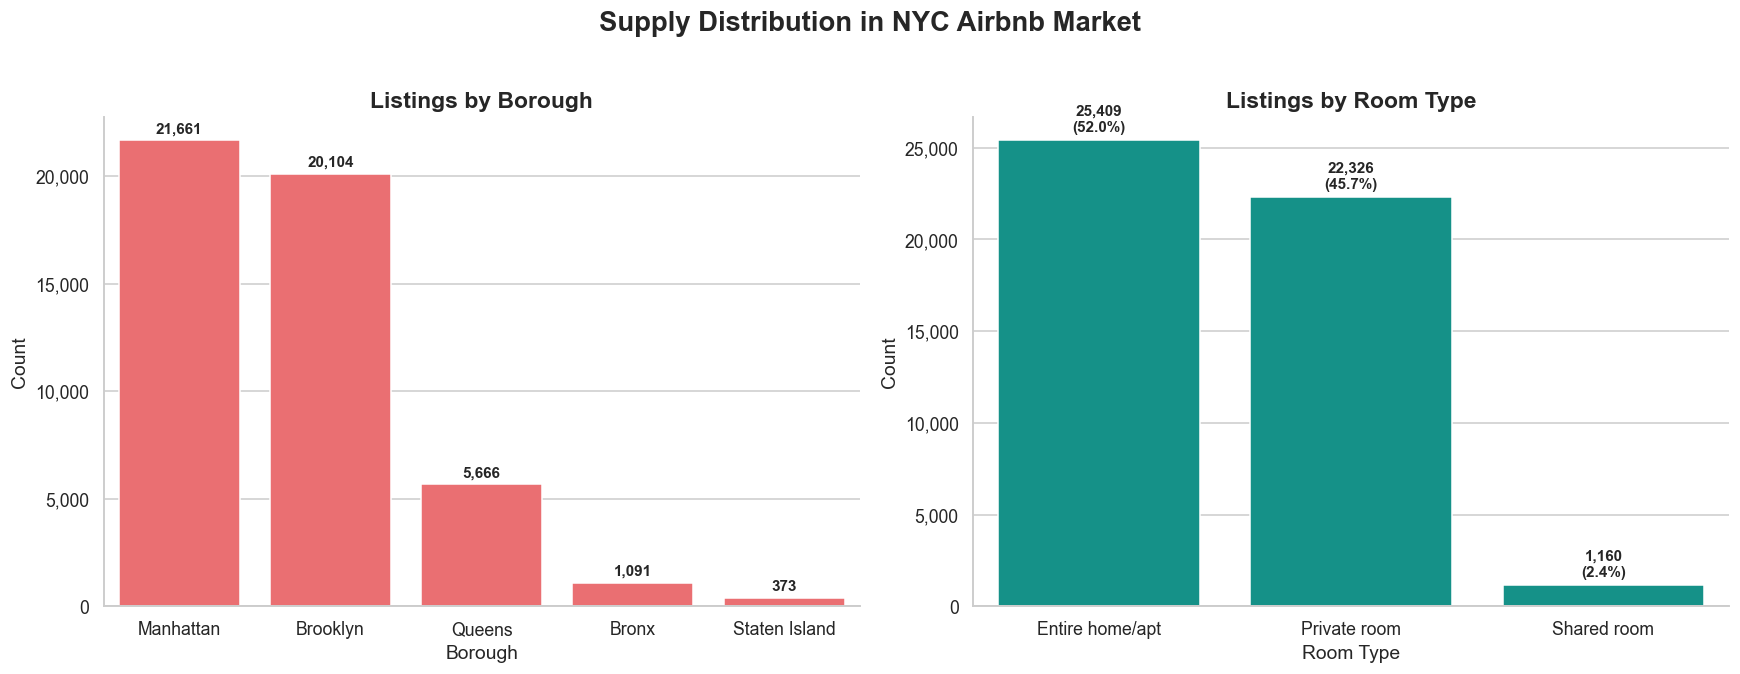

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Borough (it's called 'neighbourhood_group' in the dataset)
order_b = df['neighbourhood_group'].value_counts().index
counts_b = df['neighbourhood_group'].value_counts()
sns.countplot(x='neighbourhood_group', data=df, order=order_b, color=AIRBNB_RED, ax=axes[0])
for i, (b, cnt) in enumerate(counts_b.items()):
    axes[0].text(i, cnt + 200, f'{cnt:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Listings by Borough', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Borough'); axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Room type
order_r = df['room_type'].value_counts().index
counts_r = df['room_type'].value_counts()
sns.countplot(x='room_type', data=df, order=order_r, color=AIRBNB_TEAL, ax=axes[1])
for i, (rt, cnt) in enumerate(counts_r.items()):
    pct = cnt / len(df) * 100
    axes[1].text(i, cnt + 300, f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[1].set_title('Listings by Room Type', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Room Type'); axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Supply Distribution in NYC Airbnb Market', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Insight: Manhattan and Brooklyn account for ~80% of NYC supply. Entire homes and private rooms nearly split the market; shared rooms are statistically negligible (<3%).

### 4.2 Price Distribution & Outliers

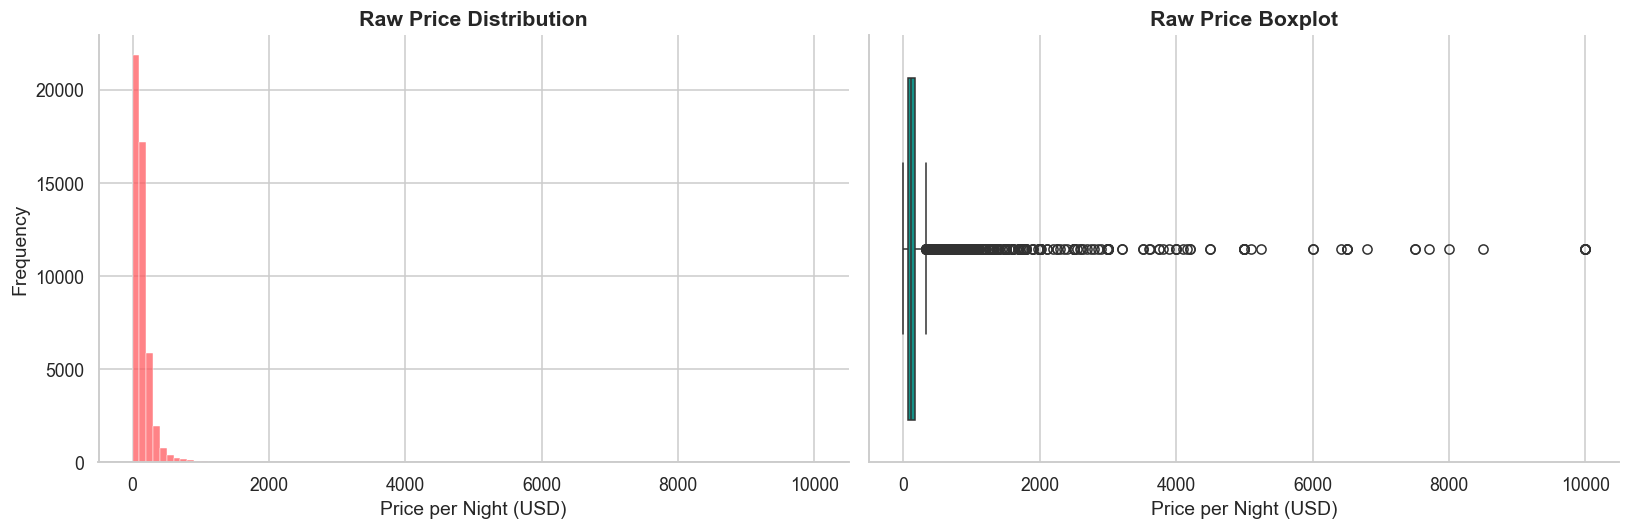

Raw price statistics:
count    48895.00
mean       152.72
std        240.15
min          0.00
25%         69.00
50%        106.00
75%        175.00
max      10000.00
Name: price, dtype: float64


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['price'], bins=100, color=AIRBNB_RED, edgecolor='white', linewidth=0.3, ax=axes[0])
axes[0].set_title('Raw Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price per Night (USD)')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['price'], color=AIRBNB_TEAL, ax=axes[1])
axes[1].set_title('Raw Price Boxplot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price per Night (USD)')

plt.tight_layout()
plt.show()

print("Raw price statistics:")
print(df['price'].describe().round(2))


Insight: The price variable is heavily right-skewed with extreme outliers reaching $10,000/night. Robust preprocessing is mandatory before modelling.

### 4.3 Average Price by Borough & Room Type

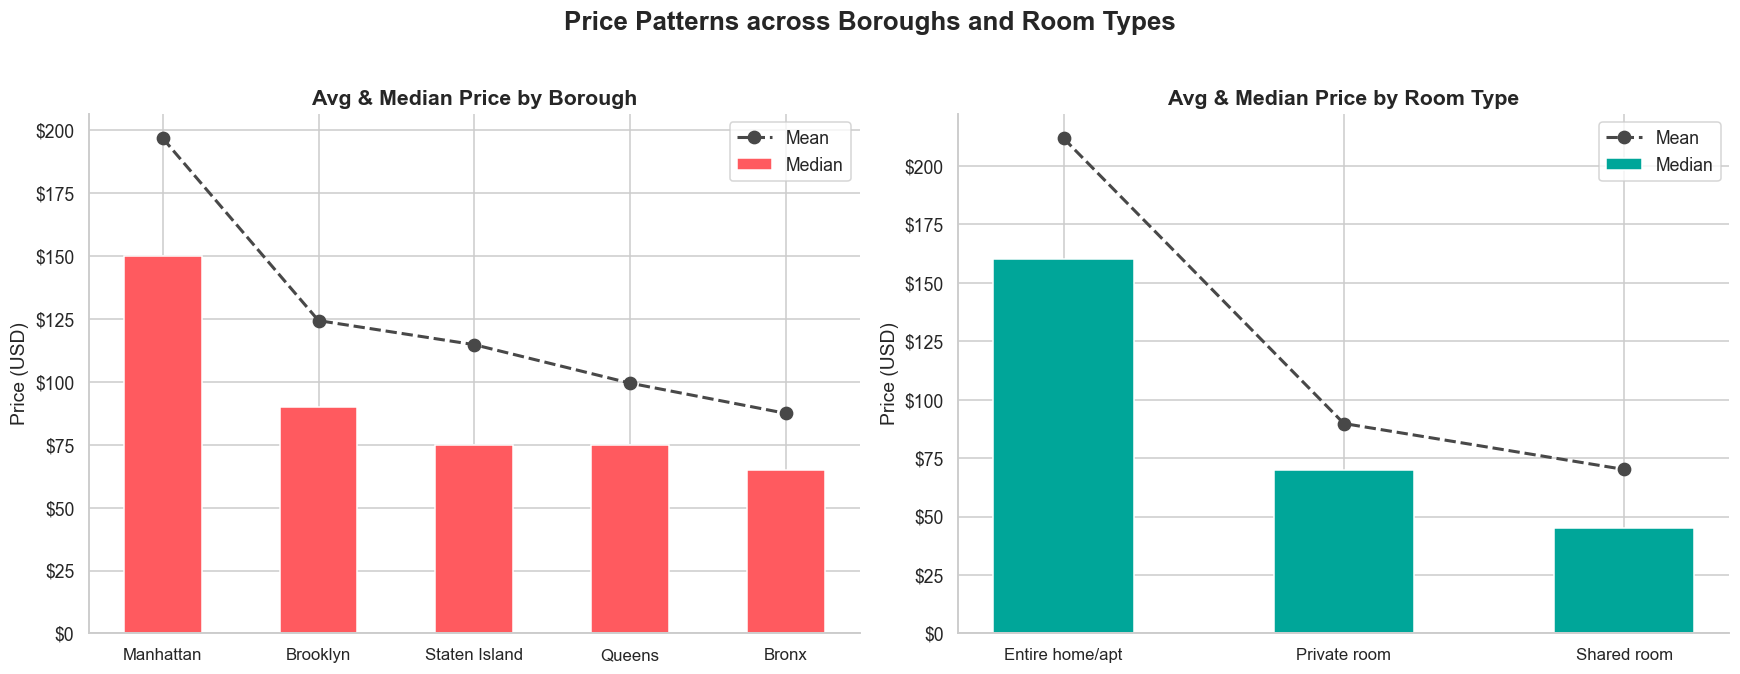

In [71]:
avg_price_borough = df.groupby('neighbourhood_group')['price'].agg(['mean', 'median']).sort_values('mean', ascending=False)
avg_price_rt = df.groupby('room_type')['price'].agg(['mean', 'median']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = range(len(avg_price_borough))
axes[0].bar(x, avg_price_borough['median'], color=AIRBNB_RED, width=0.5, label='Median')
axes[0].plot(x, avg_price_borough['mean'], 'o--', color='#484848', linewidth=2, markersize=8, label='Mean')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(avg_price_borough.index, fontsize=11)
axes[0].set_title('Avg & Median Price by Borough', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))
axes[0].legend()

x2 = range(len(avg_price_rt))
axes[1].bar(x2, avg_price_rt['median'], color=AIRBNB_TEAL, width=0.5, label='Median')
axes[1].plot(x2, avg_price_rt['mean'], 'o--', color='#484848', linewidth=2, markersize=8, label='Mean')
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(avg_price_rt.index, fontsize=11)
axes[1].set_title('Avg & Median Price by Room Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))
axes[1].legend()

plt.suptitle('Price Patterns across Boroughs and Room Types', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Insight: Manhattan is by far the most expensive borough. Entire home/apt listings command a clear privacy premium - their median is more than double that of private rooms.

### 4.4 Price Distribution by Borough × Room Type

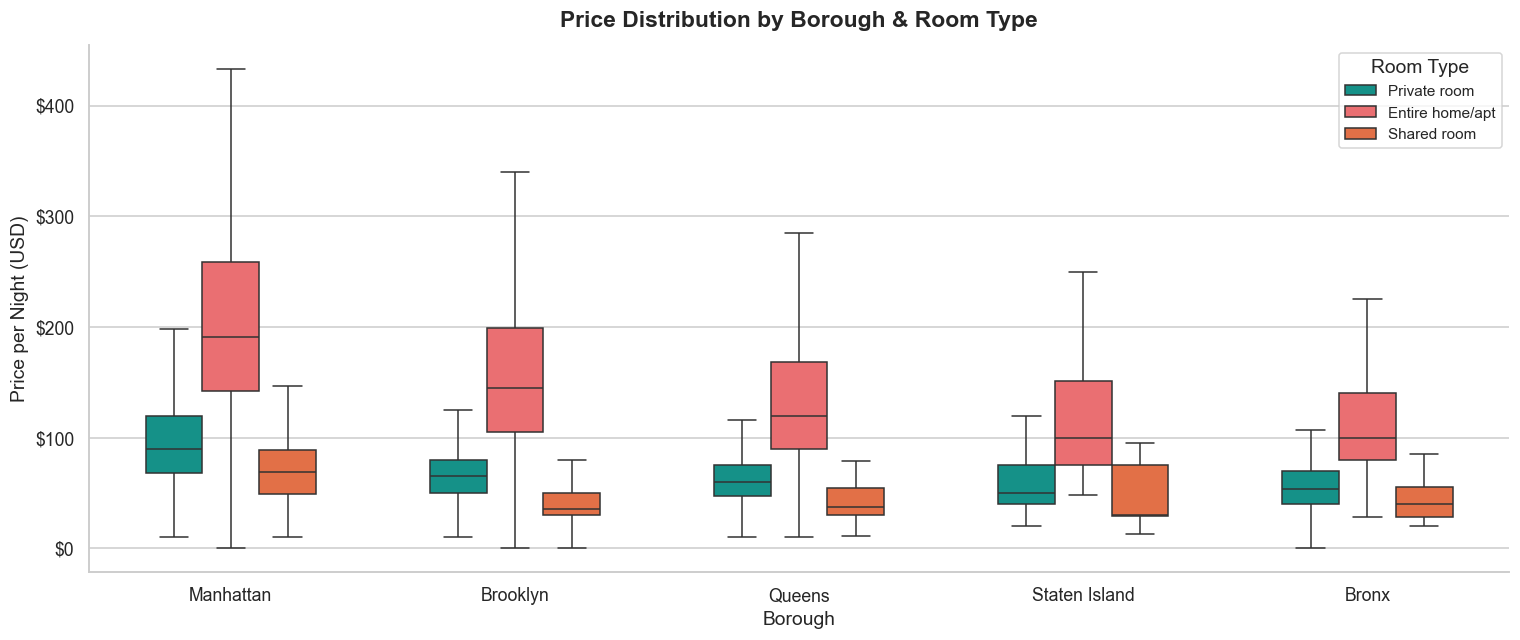

In [72]:
order = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='neighbourhood_group', y='price', hue='room_type', data=df, order=order,
            palette={'Entire home/apt': AIRBNB_RED, 'Private room': AIRBNB_TEAL, 'Shared room': AIRBNB_ORG},
            width=0.6, showfliers=False, ax=ax)
ax.set_title('Price Distribution by Borough & Room Type', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Borough'); ax.set_ylabel('Price per Night (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))
ax.legend(title='Room Type', fontsize=10)
plt.tight_layout()
plt.show()


Insight: Entire homes always sit above private rooms in every borough. Geography and room type are multiplicative price drivers, not additive.

### 4.5 Reviews Analysis

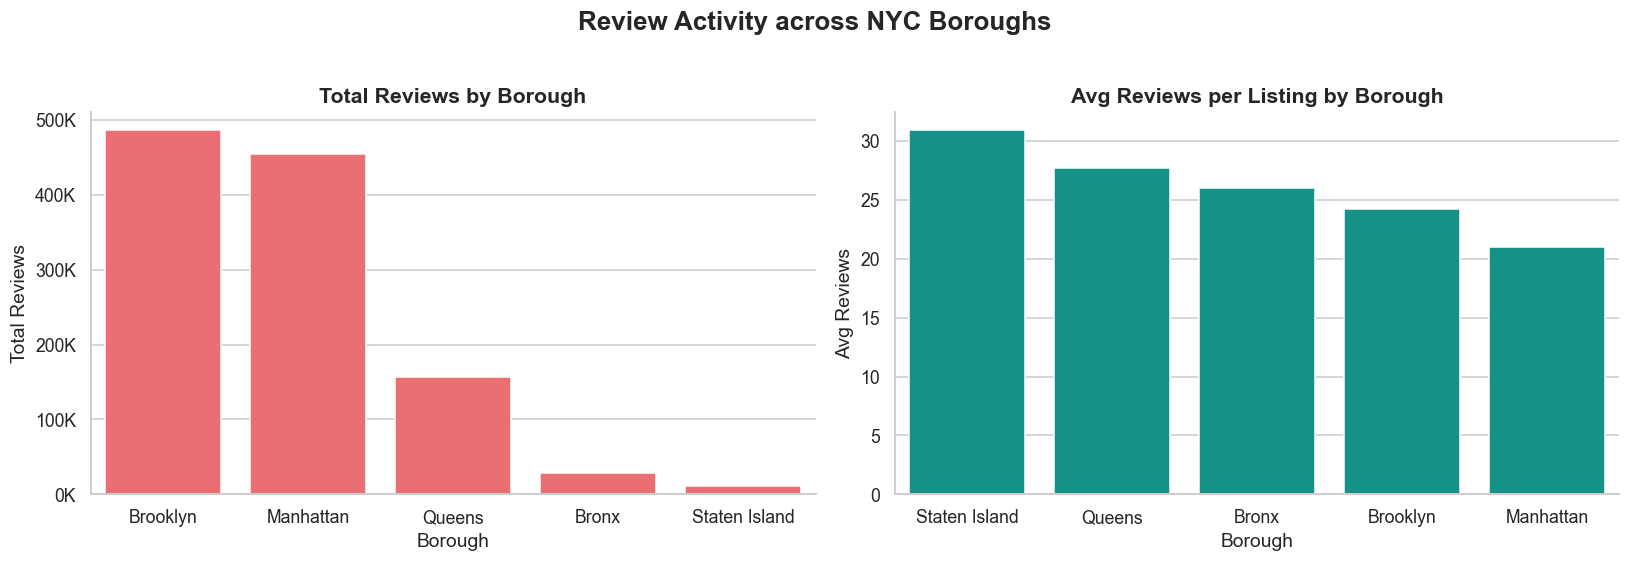

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total reviews by borough
rev_borough = df.groupby('neighbourhood_group')['number_of_reviews'].sum().sort_values(ascending=False)
sns.barplot(x=rev_borough.index, y=rev_borough.values, color=AIRBNB_RED, ax=axes[0])
axes[0].set_title('Total Reviews by Borough', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Borough'); axes[0].set_ylabel('Total Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e3)}K'))

# Avg reviews per apartment by borough
avg_rev = df.groupby('neighbourhood_group')['number_of_reviews'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rev.index, y=avg_rev.values, color=AIRBNB_TEAL, ax=axes[1])
axes[1].set_title('Avg Reviews per Listing by Borough', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Borough'); axes[1].set_ylabel('Avg Reviews')

plt.suptitle('Review Activity across NYC Boroughs', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.6 Top 10 Most Expensive & Cheapest Neighbourhoods

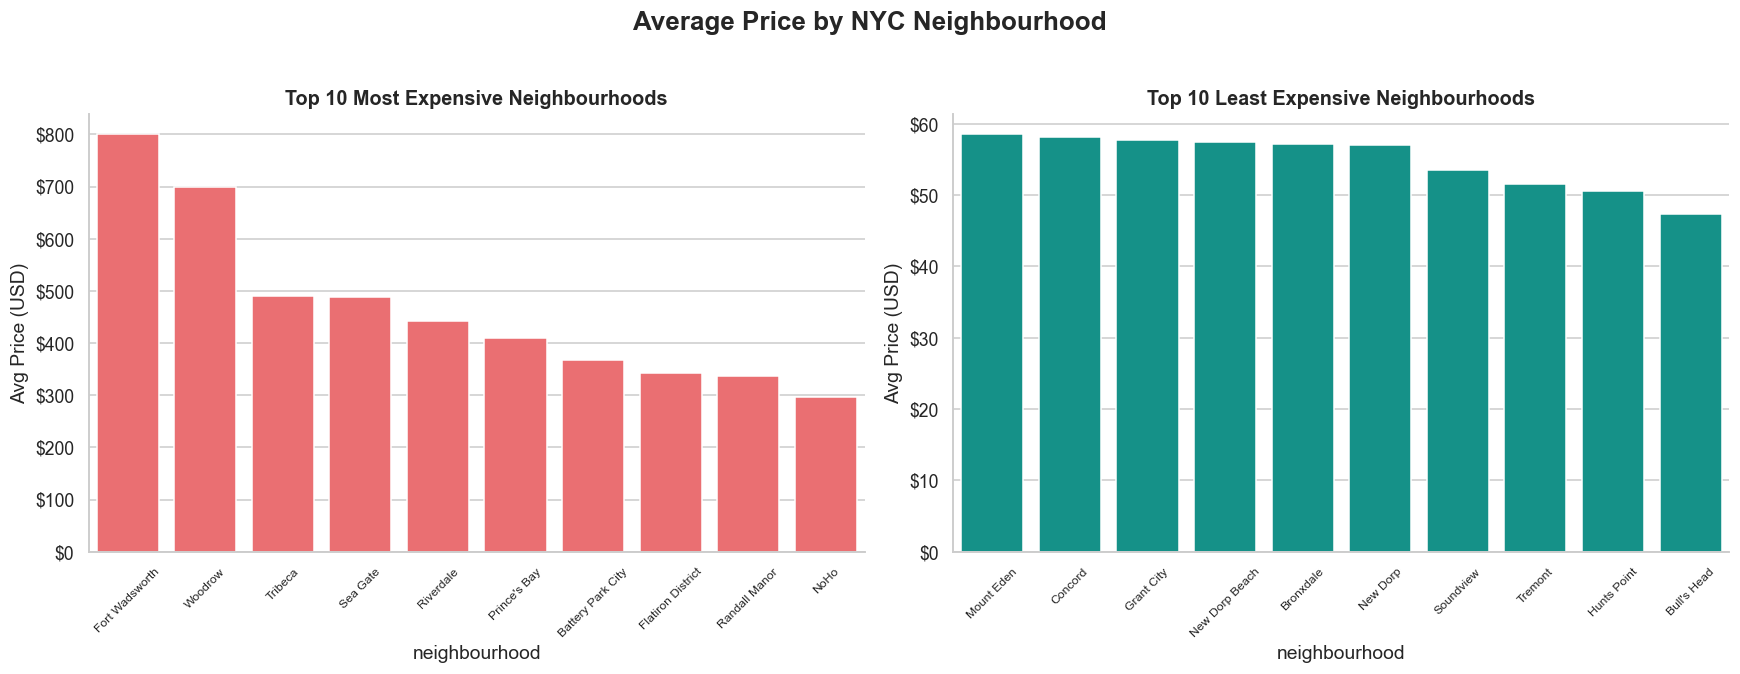

In [74]:
avg_price_neighbourhood = (df.groupby('neighbourhood')['price']
                           .mean()
                           .reset_index(name='mean price')
                           .sort_values('mean price', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Most expensive
sns.barplot(data=avg_price_neighbourhood.head(10), x='neighbourhood', y='mean price',
            color=AIRBNB_RED, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, fontsize=8)
axes[0].set_title('Top 10 Most Expensive Neighbourhoods', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Price (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))

# Least expensive
sns.barplot(data=avg_price_neighbourhood.tail(10), x='neighbourhood', y='mean price',
            color=AIRBNB_TEAL, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, fontsize=8)
axes[1].set_title('Top 10 Least Expensive Neighbourhoods', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Price (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))

plt.suptitle('Average Price by NYC Neighbourhood', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 5. Data Cleaning

Cleaning follows a deliberate sequence:

1. Fix data types - parse `last_review` as datetime
2. Fill nulls - `reviews_per_month` → 0 (no reviews yet); cosmetic text columns
3. Remove duplicates - exact duplicate rows
4. Remove zero-price listings - system artefacts, not real offers
5. Cap price outliers - IQR fence to isolate the representative market
6. Drop irrelevant columns - `id`, `host_name`, `last_review` (metadata only)


In [75]:
df['last_review'] = pd.to_datetime(df['last_review'])
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

dup_rows = df.duplicated().sum()
print(f"Duplicate rows removed: {dup_rows}")
df = df.drop_duplicates()

before = len(df)
df = df[df['price'] > 0]
print(f"Zero-price rows removed: {before - len(df)}")

quartile1, quartile3 = df['price'].quantile([0.25, 0.75])
inter_quartile_range = quartile3 - quartile1
lower_fence, upper_fence = quartile1 - 1.5 * inter_quartile_range, quartile3 + 1.5 * inter_quartile_range

before = len(df)
df = df[(df['price'] >= max(lower_fence, 1)) & (df['price'] <= upper_fence)]
after = len(df)

print(f"Price outliers removed: {before - after:,}  ({(before - after) / before * 100:.1f}%)")
print(f"Clean price range: ${df['price'].min()} – ${df['price'].max()}")
print(f"Median price: ${df['price'].median():.0f}")
print(f"Mean price: ${df['price'].mean():.2f}")

df.drop(columns=['id', 'host_name', 'last_review'], inplace=True)

print(f"\nDataset after cleaning : {df.shape[0]:,} rows × {df.shape[1]} columns")

Duplicate rows removed: 0
Zero-price rows removed: 11
Price outliers removed: 2,972  (6.1%)
Clean price range: $10 – $334
Median price: $100
Mean price: $120.00

Dataset after cleaning : 45,912 rows × 13 columns


In [76]:
audit_post = pd.DataFrame({
    'Nulls': df.isnull().sum(),
    'Null %': (df.isnull().mean() * 100).round(1),
})
audit_post.style.background_gradient(cmap='Greens_r', subset=['Null %'])

,Nulls,Null %
name,0,0.000000
host_id,0,0.000000
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
latitude,0,0.000000
longitude,0,0.000000
room_type,0,0.000000
price,0,0.000000
minimum_nights,0,0.000000
number_of_reviews,0,0.000000


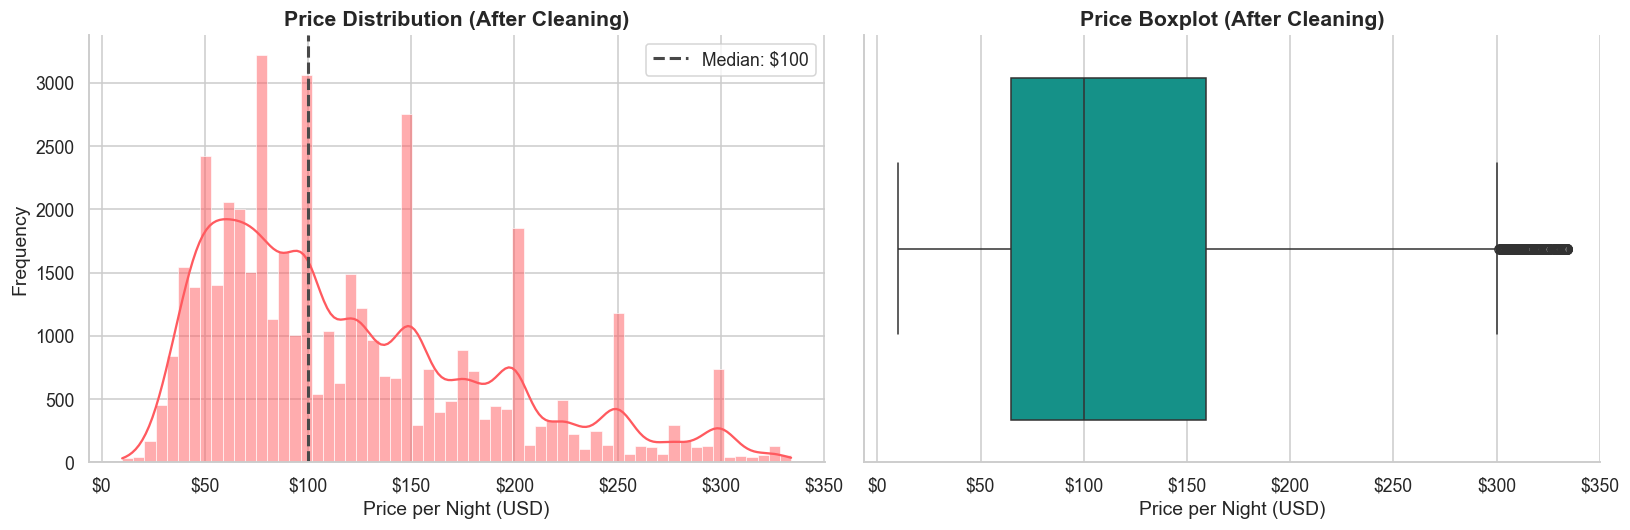

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['price'], bins=60, kde=True, color=AIRBNB_RED,
             edgecolor='white', linewidth=0.4, ax=axes[0])
median_price = df['price'].median()
axes[0].axvline(median_price, color='#484848', linestyle='--', linewidth=2,
                label=f'Median: ${median_price:.0f}')
axes[0].legend()
axes[0].set_title('Price Distribution (After Cleaning)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price per Night (USD)'); axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))

sns.boxplot(x=df['price'], color=AIRBNB_TEAL, ax=axes[1])
axes[1].set_title('Price Boxplot (After Cleaning)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price per Night (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))

plt.tight_layout()
plt.show()

---
## 6. Feature Engineering & Correlation Analysis

We create three derived features to enrich the model before running correlation analysis.

| Feature | Rationale |
|---------|-----------|
| `dist_to_center` | Haversine distance from each listing to Times Square - a concrete numerical representation of proximity to the city centre |
| `neighborhood_tier` | Median nightly price of the neighbourhood - a continuous "prestige" signal that avoids one-hot encoding 200+ neighbourhoods |
| `has_reviews` | Binary flag separating active listings from new/unreviewed ones |

### Why `neighborhood_tier` instead of one-hot encoding?

The dataset contains ~220 unique neighbourhoods. One-hot encoding would add 219 binary columns, dramatically increasing dimensionality and introducing sparsity that hurts generalisation. Instead, we replace the categorical neighbourhood label with a single continuous number - the median price of that neighbourhood, computed from the full cleaned dataset. This encoding: preserves the ordinal ranking of neighbourhoods (expensive vs cheap areas), reduces 220 classes to 1 meaningful continuous feature and it also means that a higher tier value = a more expensive area

In [78]:
# Feature 1: Distance to Times Square 
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371  # Earth radius in km
    latitude_rad1, latitude_rad2 = np.radians(lat1), np.radians(lat2)
    difference_latitude_rad = np.radians(lat2 - lat1)
    difference_longitude_rad = np.radians(lon2 - lon1)
    central_angle = np.sin(difference_latitude_rad / 2) ** 2 + np.cos(latitude_rad1) * np.cos(latitude_rad2) * np.sin(difference_longitude_rad / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(central_angle))

TIMES_SQUARE_LAT, TIMES_SQUARE_LON = 40.7580, -73.9855
df['dist_to_center'] = haversine_distance(df['latitude'], df['longitude'],
                                           TIMES_SQUARE_LAT, TIMES_SQUARE_LON)

# Feature 2: Neighbourhood tier (median price of neighbourhood)
neighbourhood_median = df.groupby('neighbourhood')['price'].median()
df['neighborhood_tier'] = df['neighbourhood'].map(neighbourhood_median)

# Feature 3: has_reviews binary flag, we use reviews_per_month as a proxy - >0 means the listing has been reviewed
df['has_reviews'] = (df['reviews_per_month'] > 0).astype(int)

df[['dist_to_center', 'neighborhood_tier', 'has_reviews']].describe().round(2)

,dist_to_center,neighborhood_tier,has_reviews
count,45912.00,45912.00,45912.0
mean,7.28,107.78,0.8
std,4.42,37.82,0.4
min,0.07,34.50,0.0
25%,4.02,79.00,1.0
50%,6.71,99.00,1.0
75%,9.53,140.00,1.0
max,35.90,249.00,1.0


### 6.1 Correlation Heatmap

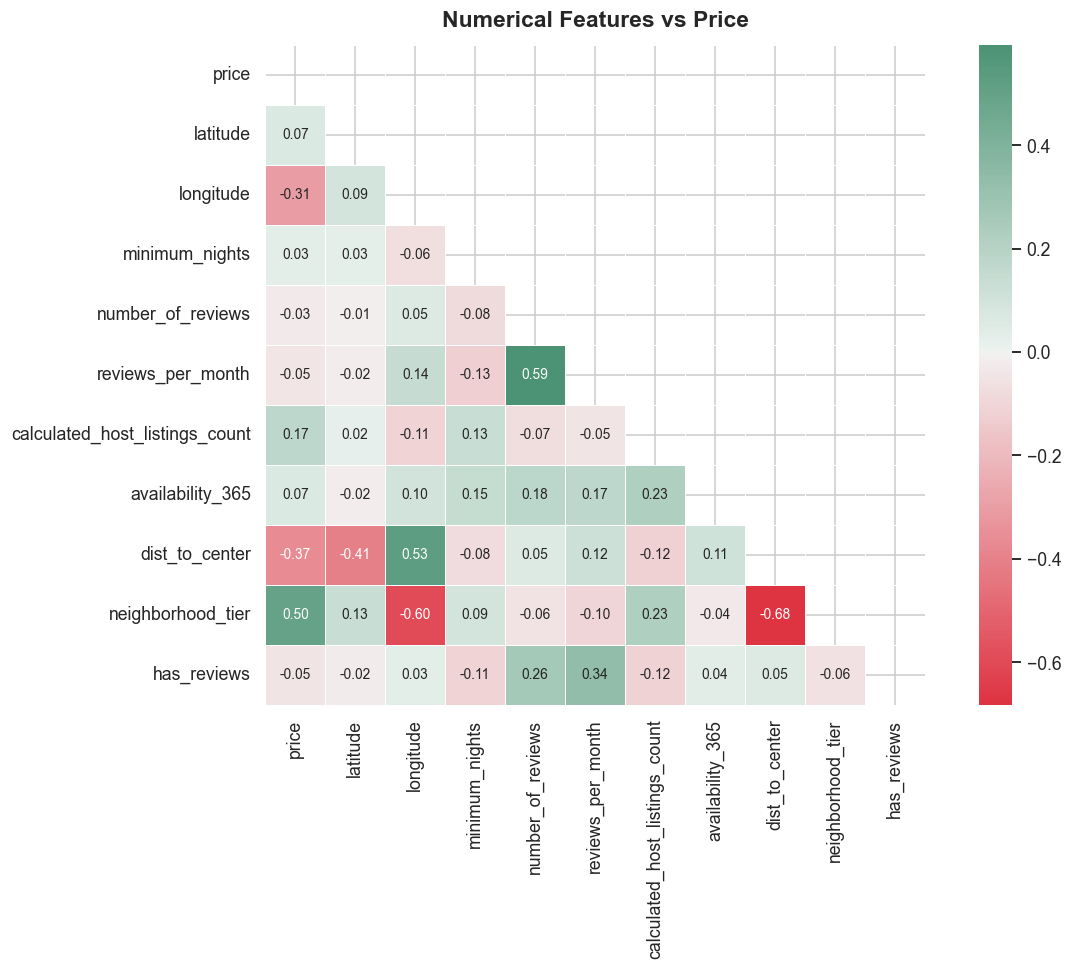

In [79]:
numeric_cols = ['price', 'latitude', 'longitude', 'minimum_nights',
                'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 'availability_365',
                'dist_to_center', 'neighborhood_tier', 'has_reviews']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(10, 150, s=80, as_cmap=True),
            center=0, linewidths=0.5, square=True, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Numerical Features vs Price', fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


Key Insight: `neighborhood_tier` shows the strongest correlation with `price` (r ≈ 0.50), validating location as the dominant price signal. `reviews_per_month` and `number_of_reviews` have a moderate negative correlation with price - budget listings are booked and reviewed more frequently.

Most individual features exhibit weak linear correlation with price, which confirms that non-linear ensemble methods will outperform linear baselines.

### 6.2 Checking for Collinearity

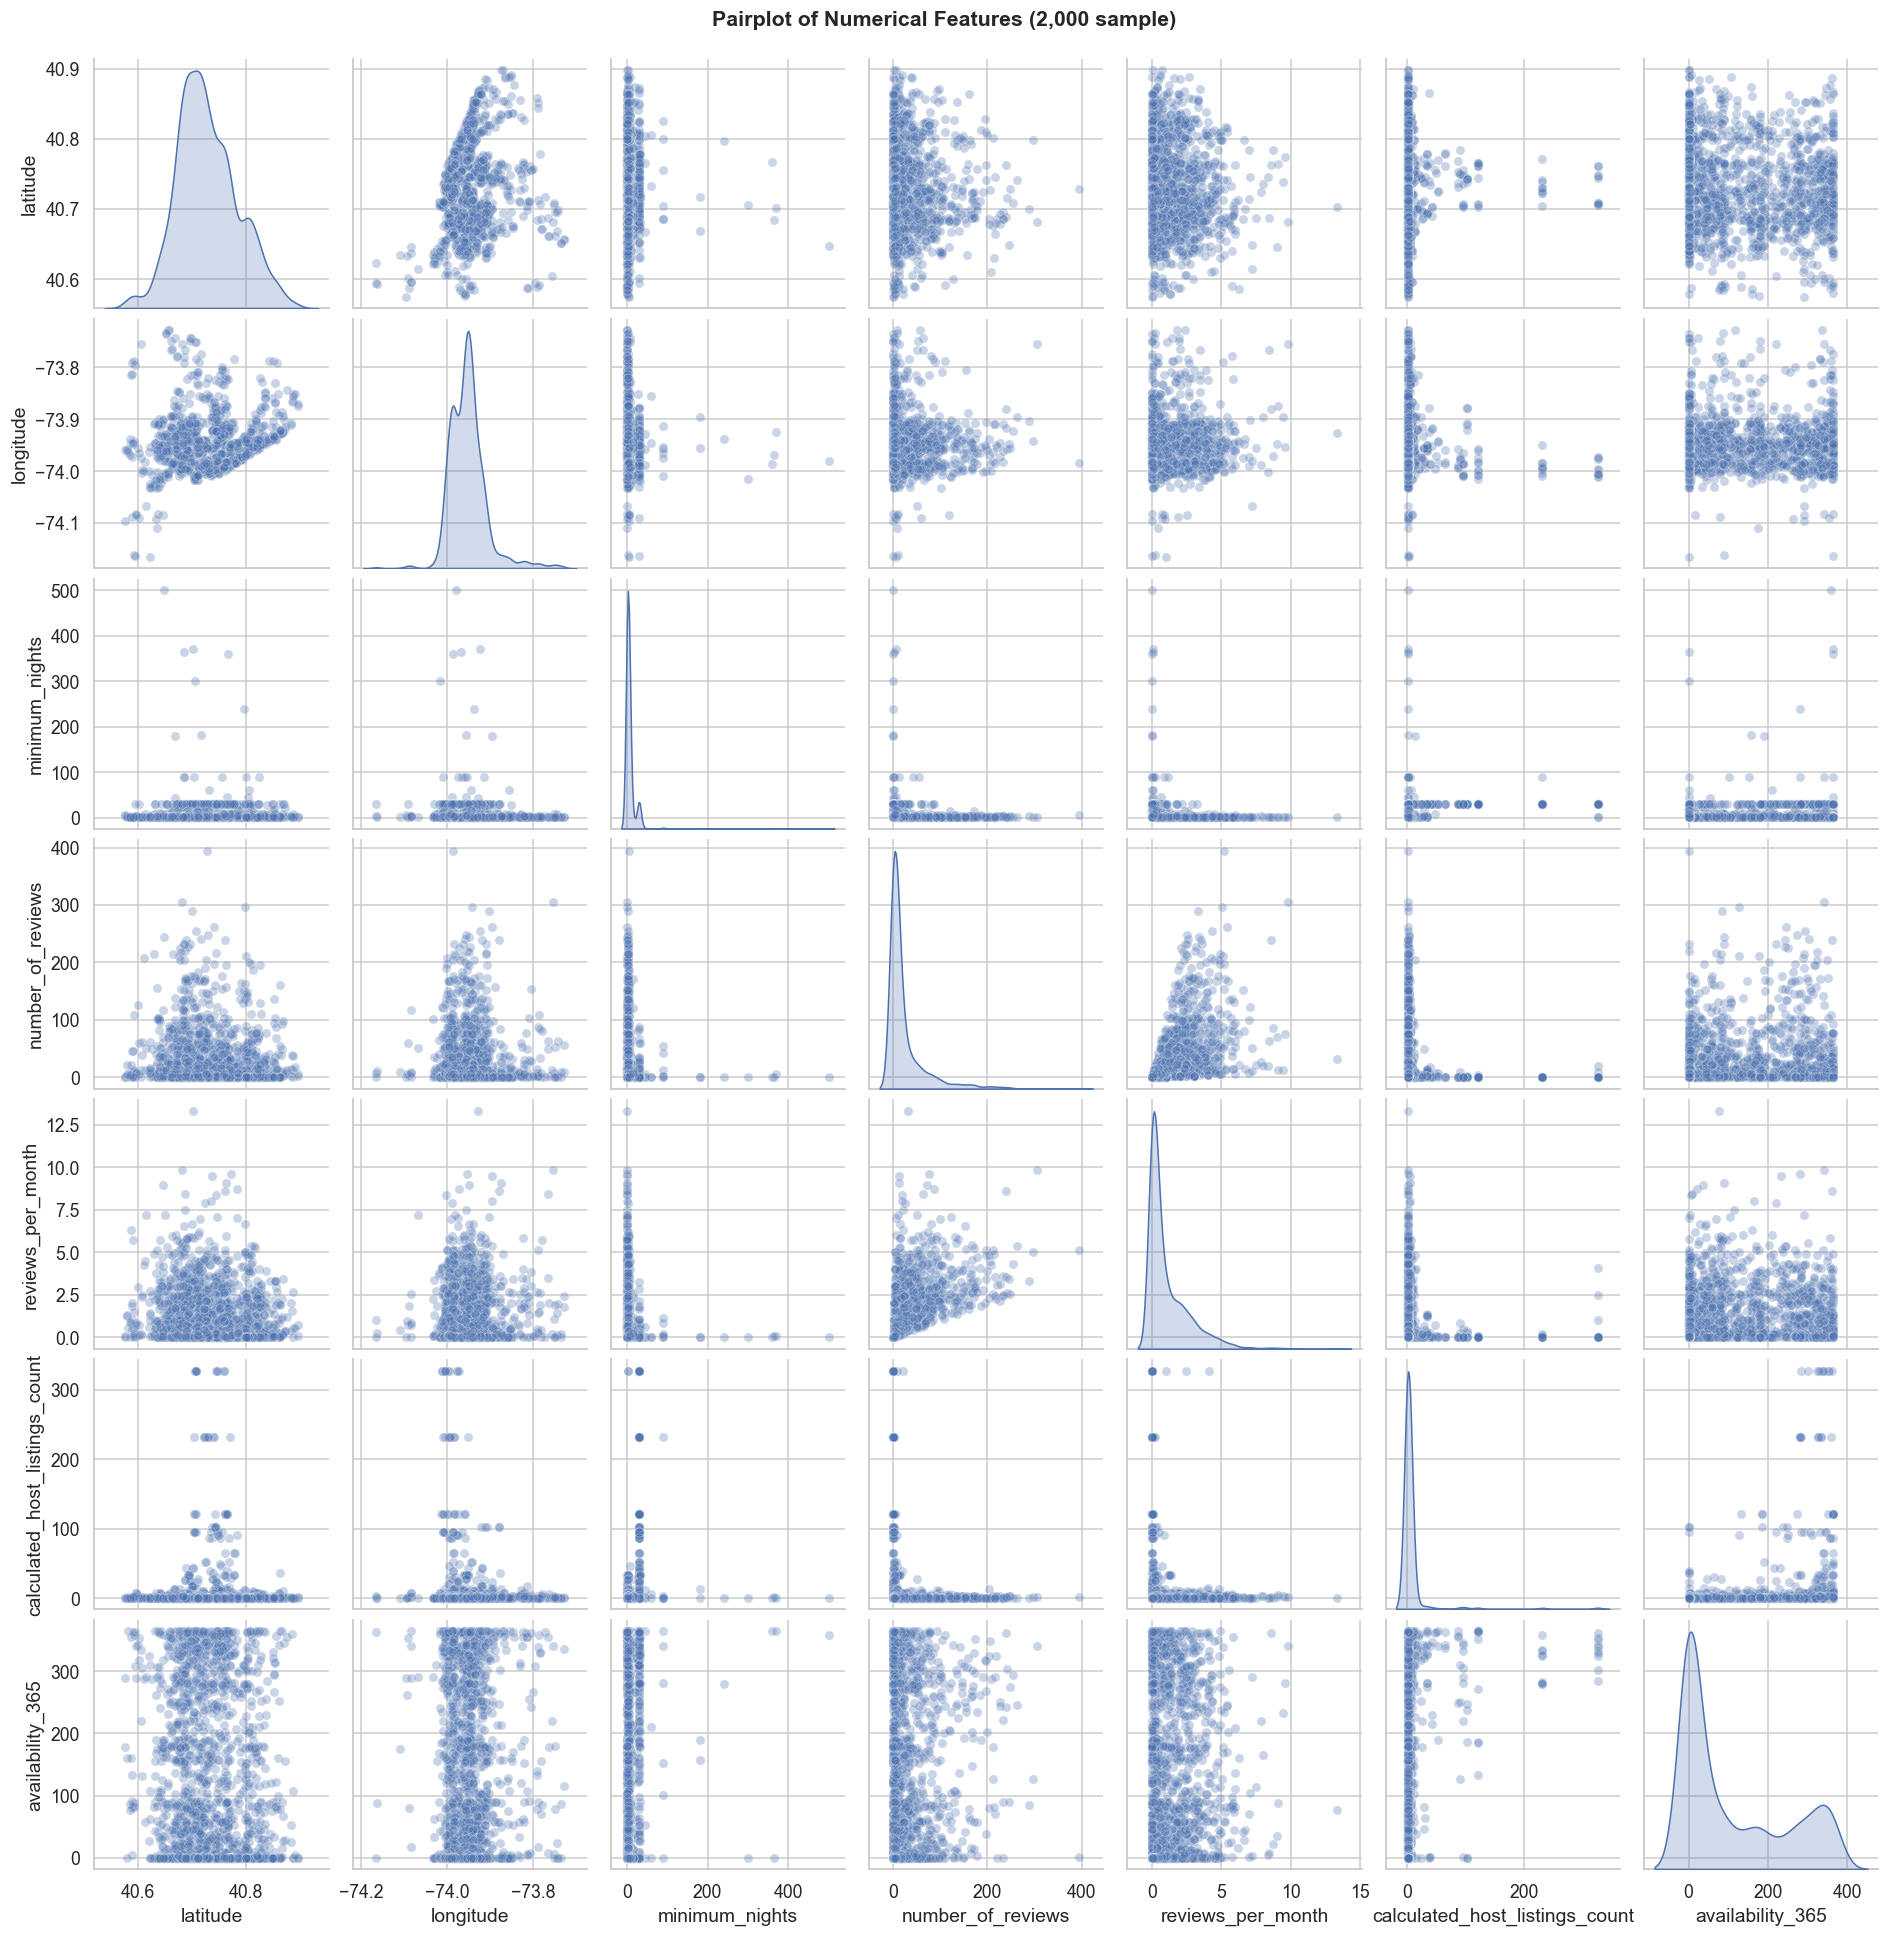

In [80]:
collin_check = ['latitude', 'longitude', 'minimum_nights',
                'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 'availability_365']

sample = df[collin_check].sample(2000, random_state=42)
sns.pairplot(sample, plot_kws={'alpha': 0.3, 'rasterized': True}, diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features (2,000 sample)', y=1.01, fontsize=14, fontweight='bold')
plt.show()


Observation: No severe collinearity is detected among numerical predictors. The pair `reviews_per_month` / `number_of_reviews` shows a mild positive relationship, as expected, but not strong enough to warrant removal

### 6.3 Neighbourhood Tier vs Price & Availability

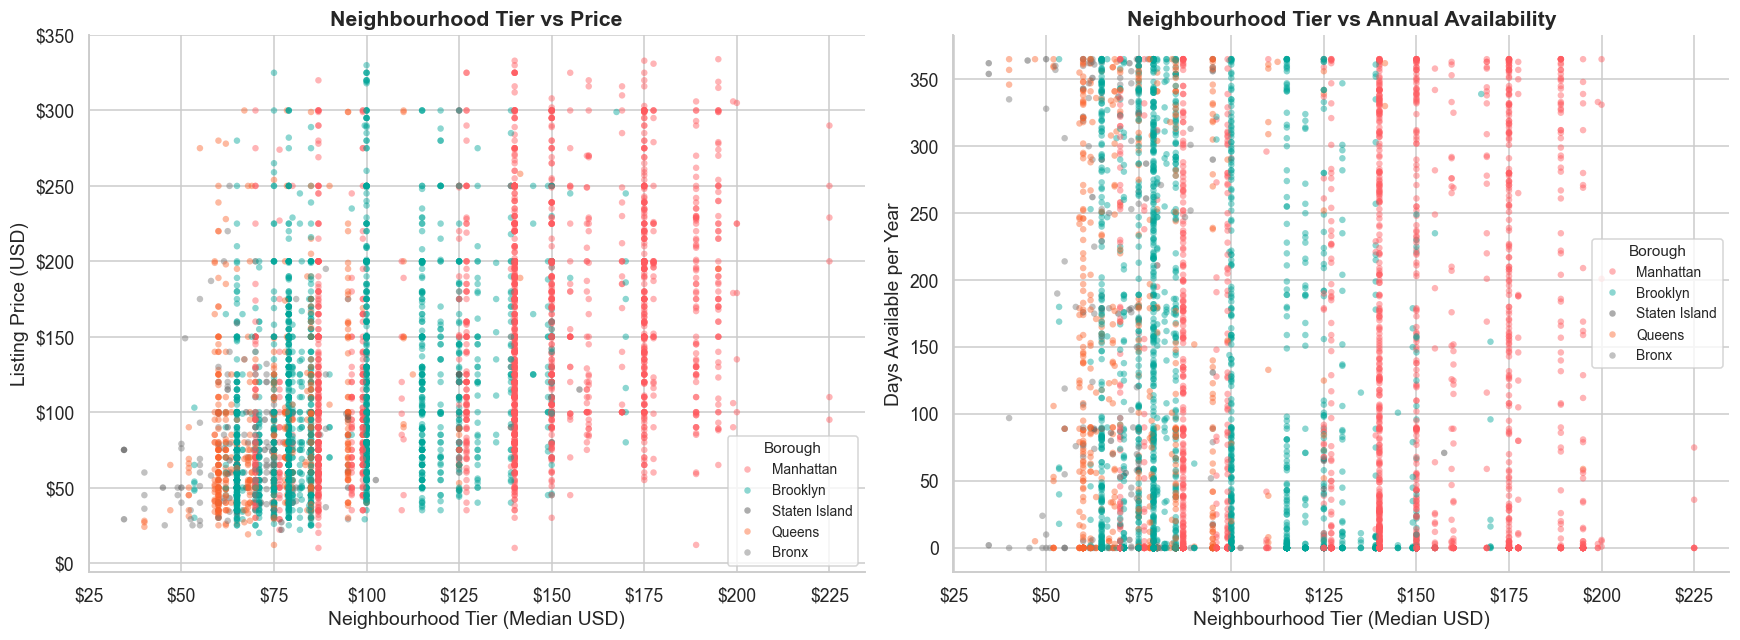

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tier vs Price
sample_plot = df.sample(5000, random_state=42)
palette_b = {'Manhattan': AIRBNB_RED, 'Brooklyn': AIRBNB_TEAL, 'Queens': AIRBNB_ORG,
             'Bronx': '#767676', 'Staten Island': '#484848'}
sns.scatterplot(x='neighborhood_tier', y='price',
                hue='neighbourhood_group', data=sample_plot,
                palette=palette_b, alpha=0.45, edgecolor='none', s=18, ax=axes[0])
axes[0].set_title('Neighbourhood Tier vs Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Neighbourhood Tier (Median USD)')
axes[0].set_ylabel('Listing Price (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))

# Tier vs Availability
sns.scatterplot(x='neighborhood_tier', y='availability_365',
                hue='neighbourhood_group', data=sample_plot,
                palette=palette_b, alpha=0.45, edgecolor='none', s=18, ax=axes[1])
axes[1].set_title('Neighbourhood Tier vs Annual Availability', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Neighbourhood Tier (Median USD)')
axes[1].set_ylabel('Days Available per Year')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))

for ax in axes:
    ax.legend(title='Borough', fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()


---
## 7. Data Preparation for Training

Steps:
1. Drop columns not useful for prediction (`name`, `neighbourhood` encoded via tier, `host_id`)
2. Apply log-transformation to the target `price` - stabilises variance and handles residual right skew
3. One-hot encode categorical variables (`neighbourhood_group`, `room_type`)
4. Train / Test split — 80% train, 20% test
5. StandardScaler - applied only for linear models; tree-based models use raw features

### On the choice of target transformation

Three options were considered for transforming the target variable `price`:

| Approach | Formula | Pro | Con |
|---|---|---|---|
| No transform | raw price | Simplest; direct interpretation | Right skew inflates loss; large outliers dominate |
| Log transform | `log1p(price)` | Compresses right tail; stabilises variance; widely used for price data | Slight bias when inverting predictions near zero |
| Z-normalization | `(price − μ) / σ` | Mean=0, unit variance; linear-friendly | Does not fix skew; mean/std affected by residual outliers |

We chose log1p because the cleaned price distribution is still right-skewed (median $100, max $334), and the log transform directly addresses this structural asymmetry. Z-normalization would standardise the scale but leave the skew intact, which is less appropriate here.

In [82]:
cols_to_drop = ['name', 'host_id', 'neighbourhood']   # neighbourhood encoded via neighborhood_tier
df_model = df.drop(columns=cols_to_drop)

df_model['price_log'] = np.log1p(df_model['price'])

df_final = pd.get_dummies(df_model, columns=['neighbourhood_group', 'room_type'], drop_first=True)

print("Columns in modelling dataset:")
print(list(df_final.columns))
print(f"\nFinal shape: {df_final.shape}")


Columns in modelling dataset:
['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'dist_to_center', 'neighborhood_tier', 'has_reviews', 'price_log', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Private room', 'room_type_Shared room']

Final shape: (45912, 18)


In [83]:
X = df_final.drop(columns=['price', 'price_log'])
y = df_final['price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")

Train set: 36,729 rows
Test set: 9,183 rows


---
## 8. Model Comparison

We evaluate five distinct algorithms covering the spectrum from simple linear baselines to gradient boosting.

| Model | Class | Key Characteristic |
|---|---|---|
| **Linear Regression** | Linear | Baseline; assumes linear feature-price relationship |
| **Ridge Regression** | Linear + L2 | Mitigates multicollinearity from OHE neighbourhood dummies |
| **Random Forest** | Ensemble (Bagging) | Robust to outliers; averages 100+ trees |
| **XGBoost** | Ensemble (Boosting) | Sequential correction of residuals; excellent on tabular data |
| **LightGBM** | Ensemble (Boosting) | Leaf-wise growth; extremely fast on large datasets |

**Evaluation metrics:**
- **MAE** (Mean Absolute Error) - average dollar error in original scale
- **RMSE** (Root Mean Squared Error) - penalises large errors more heavily
- **R^2** - proportion of variance explained


In [84]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": (LinearRegression(), True),
    "Ridge Regression": (Ridge(alpha=1.0), True),
    "Random Forest": (RandomForestRegressor(n_estimators=100, max_depth=10,
                                                  random_state=42, n_jobs=-1), False),
}

models["XGBoost"] = (XGBRegressor(n_estimators=300, learning_rate=0.05,
                                       max_depth=6, random_state=42,
                                       verbosity=0), False)
models["LightGBM"] = (LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                         random_state=42, verbose=-1), False)

results = []

for name, (model, scaled) in models.items():
    Xtr = X_train_scaled if scaled else X_train
    Xte = X_test_scaled  if scaled else X_test

    start = time()
    model.fit(Xtr, y_train)
    train_time = time() - start

    y_pred_log = model.predict(Xte)

    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2  = r2_score(y_true, y_pred)

    results.append({"Model": name, "MAE ($)": round(mae, 2),
                    "RMSE ($)": round(rmse, 2), "R^2 Score": round(r2, 4),
                    "Train Time (s)": round(train_time, 2)})
    print(f"{name:<19} | MAE: ${mae:.3f} | RMSE: ${rmse:.3f} | R^2: {r2:.6f}")

df_perf = pd.DataFrame(results).sort_values("MAE ($)")

Linear Regression   | MAE: $33.044 | RMSE: $47.207 | R^2: 0.507841
Ridge Regression    | MAE: $33.044 | RMSE: $47.207 | R^2: 0.507840
Random Forest       | MAE: $30.745 | RMSE: $44.182 | R^2: 0.568898
XGBoost             | MAE: $30.411 | RMSE: $43.736 | R^2: 0.577563
LightGBM            | MAE: $30.381 | RMSE: $43.732 | R^2: 0.577638


### 8.1 Model Scores Table

In [85]:
# model comparison table
df_display = df_perf.set_index("Model")
display(df_display.style
        .background_gradient(cmap='RdYlGn_r', subset=['MAE ($)', 'RMSE ($)'])
        .background_gradient(cmap='RdYlGn', subset=['R^2 Score'])
        .format({'MAE ($)': '${:.2f}', 'RMSE ($)': '${:.2f}',
                 'R^2 Score': '{:.4f}', 'Train Time (s)': '{:.2f}s'})
        .set_caption("Lower MAE/RMSE = better  |  Higher R^2 = better"))

,MAE ($),RMSE ($),R^2 Score,Train Time (s)
Model,,,,
LightGBM,$30.38,$43.73,0.5776,0.36s
XGBoost,$30.41,$43.74,0.5776,0.49s
Random Forest,$30.74,$44.18,0.5689,1.23s
Ridge Regression,$33.04,$47.21,0.5078,0.01s
Linear Regression,$33.04,$47.21,0.5078,0.01s


### 8.2 Visual Comparison

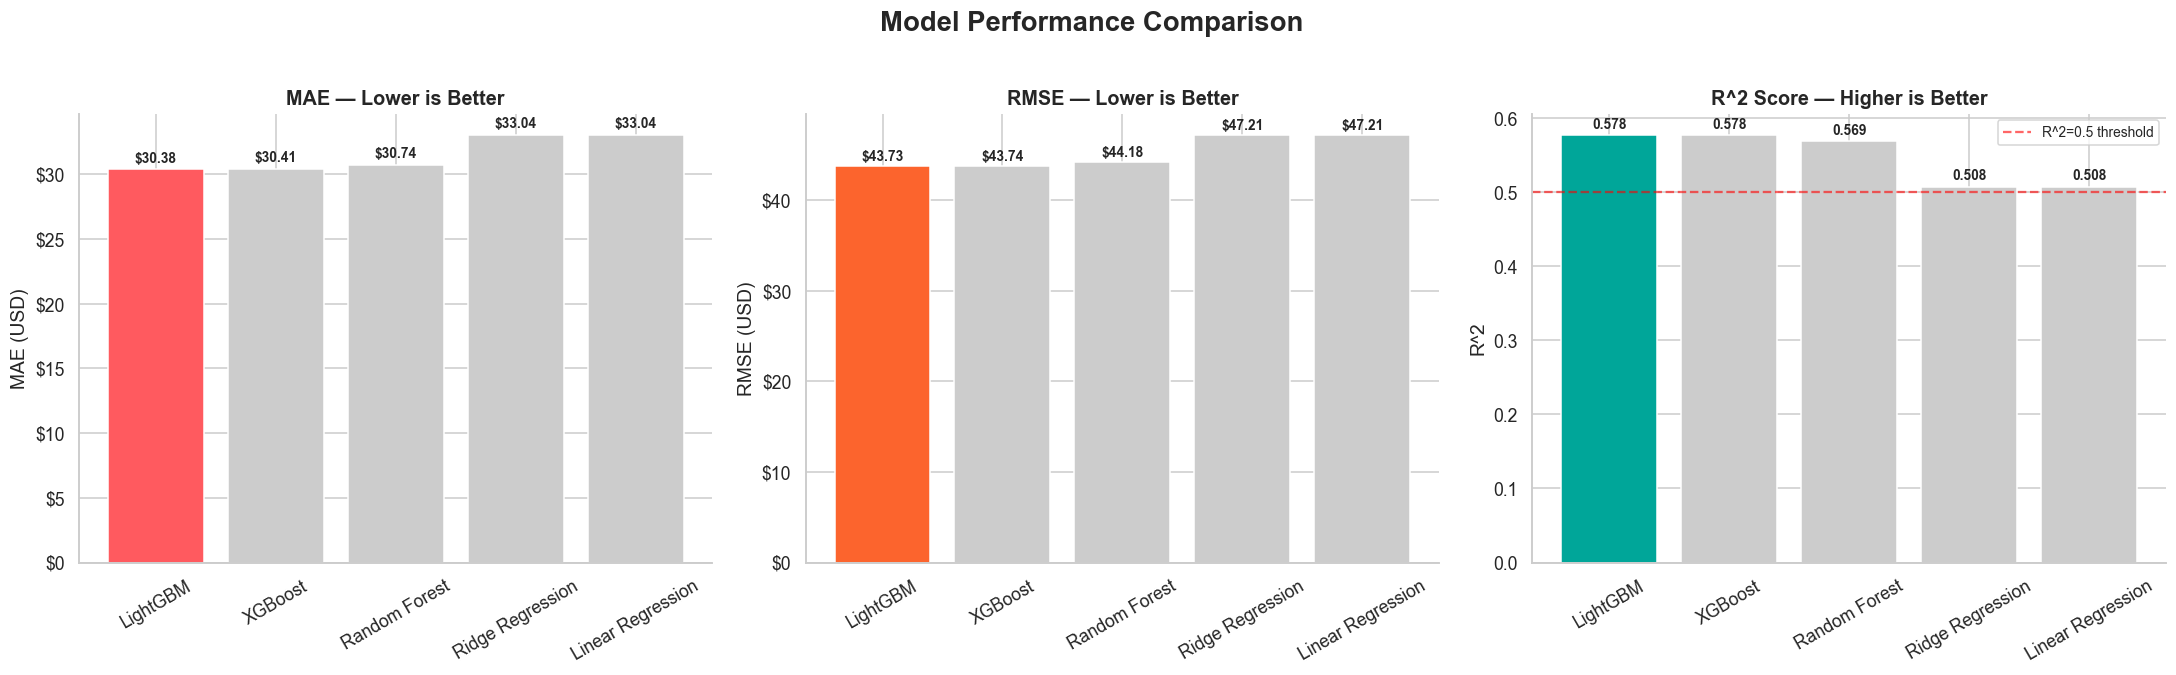

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.set_theme(style='whitegrid')

# MAE
sorted_mae = df_perf.sort_values('MAE ($)')
bars = axes[0].bar(sorted_mae['Model'], sorted_mae['MAE ($)'],
                   color=[AIRBNB_RED if i == 0 else '#cccccc' for i in range(len(sorted_mae))])
axes[0].set_title('MAE — Lower is Better', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('MAE (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))
for bar, val in zip(bars, sorted_mae['MAE ($)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'${val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# RMSE
sorted_rmse = df_perf.sort_values('RMSE ($)')
bars2 = axes[1].bar(sorted_rmse['Model'], sorted_rmse['RMSE ($)'],
                    color=[AIRBNB_ORG if i == 0 else '#cccccc' for i in range(len(sorted_rmse))])
axes[1].set_title('RMSE — Lower is Better', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('RMSE (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))
for bar, val in zip(bars2, sorted_rmse['RMSE ($)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'${val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# R^2
sorted_r2 = df_perf.sort_values('R^2 Score', ascending=False)
bars3 = axes[2].bar(sorted_r2['Model'], sorted_r2['R^2 Score'],
                    color=[AIRBNB_TEAL if i == 0 else '#cccccc' for i in range(len(sorted_r2))])
axes[2].set_title('R^2 Score — Higher is Better', fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_ylabel('R^2')
axes[2].axhline(0.5, color='red', linestyle='--', alpha=0.6, label='R^2=0.5 threshold')
axes[2].legend(fontsize=9)
for bar, val in zip(bars3, sorted_r2['R^2 Score']):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 8.3 Feature Importance of the Best Model

Best model by MAE: LightGBM


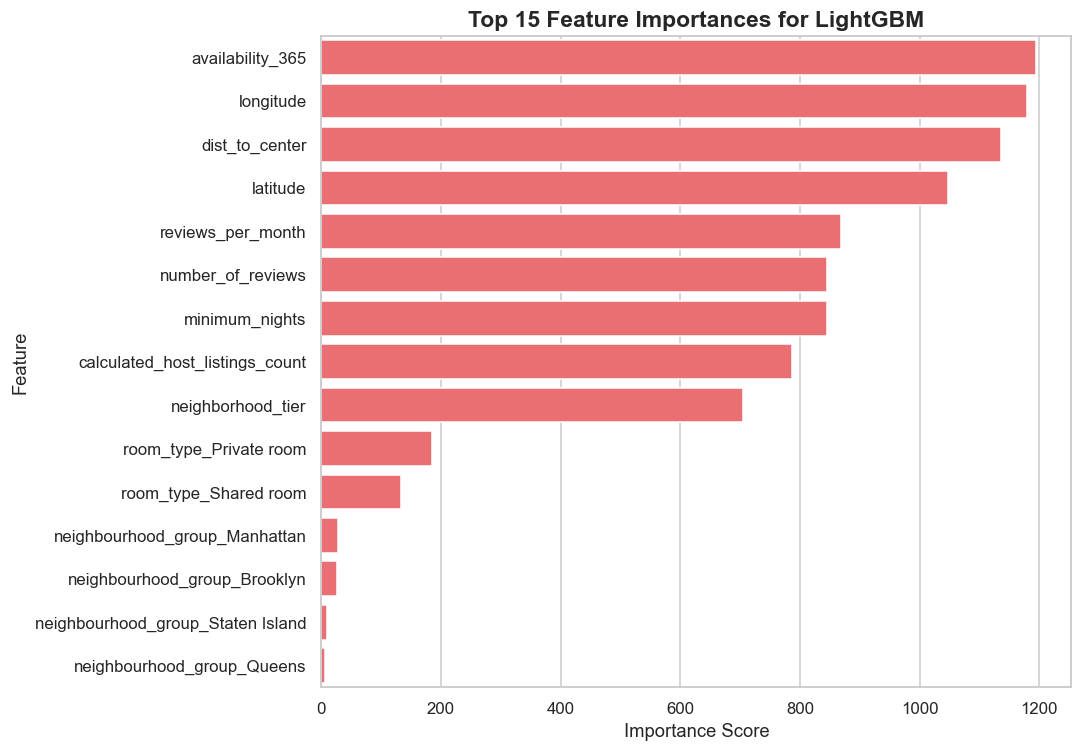

In [87]:
best_model_name = df_perf.iloc[0]['Model']
best_model_obj = models[best_model_name][0]

print(f"Best model by MAE: {best_model_name}")

if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    feat_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df, color=AIRBNB_RED, ax=ax)
    ax.set_title(f'Top 15 Feature Importances for {best_model_name}', fontsize=15, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_.")


---
## 9. Best Model Selection & Hyperparameter Tuning

The model with the lowest MAE is selected as the final candidate. We then apply **GridSearchCV** with 5-fold cross-validation to find the optimal hyperparameters.


In [88]:
best_model_name = df_perf.iloc[0]['Model']
print(f"Selected model for tuning: {best_model_name}")

Selected model for tuning: LightGBM


In [89]:
# Parameter grid (adapts to winning model)
if best_model_name == "Random Forest":
    tuning_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 8, 15],
        'min_samples_split': [2, 5],
    }
elif best_model_name == "XGBoost":
    tuning_model = XGBRegressor(random_state=42, verbosity=0)
    param_grid = {
        'n_estimators': [200, 400],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth': [4, 6, 8],
    }
elif best_model_name == "LightGBM":
    tuning_model = LGBMRegressor(random_state=42, verbose=-1)
    param_grid = {
        'n_estimators': [200, 400],
        'learning_rate': [0.03, 0.05, 0.1],
        'num_leaves': [31, 63],
    }
else:
    tuning_model = Ridge()
    param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}

Xtr_tune = X_train_scaled if best_model_name in ["Linear Regression", "Ridge Regression"] else X_train
Xte_tune = X_test_scaled  if best_model_name in ["Linear Regression", "Ridge Regression"] else X_test

print(f"Running GridSearchCV for {best_model_name}...")
print(f"Parameter grid: {param_grid}")

Running GridSearchCV for LightGBM...
Parameter grid: {'n_estimators': [200, 400], 'learning_rate': [0.03, 0.05, 0.1], 'num_leaves': [31, 63]}


In [91]:
gscv = GridSearchCV(
    estimator = tuning_model,
    param_grid = param_grid,
    cv = 5,
    scoring = 'neg_mean_absolute_error',
    n_jobs = -1,
    verbose = 1,
)

gscv.fit(Xtr_tune, y_train)

print(f"\nBest parameters: {gscv.best_params_}")
print(f"Best CV MAE: ${-gscv.best_score_:.4f} (log scale)")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'learning_rate': 0.05, 'n_estimators': 400, 'num_leaves': 63}
Best CV MAE: $0.2575 (log scale)


In [ ]:
y_pred_log_tuned = gscv.predict(Xte_tune)

y_pred_tuned = np.expm1(y_pred_log_tuned)
y_true_test = np.expm1(y_test)

mae_tuned = mean_absolute_error(y_true_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_true_test, y_pred_tuned))
r2_tuned = r2_score(y_true_test, y_pred_tuned)

# Baseline (untuned best model)
baseline_row = df_perf.iloc[0]

print("=" * 50)
print(f"{'Metric':<12}  {'Baseline':>12}  {'Tuned':>12}")
print("=" * 50)
print(f"{'MAE ($)':<12}  {'${:.2f}'.format(baseline_row['MAE ($)']):>12}  {'${:.2f}'.format(mae_tuned):>12}")
print(f"{'RMSE ($)':<12}  {'${:.2f}'.format(baseline_row['RMSE ($)']):>12}  {'${:.2f}'.format(rmse_tuned):>12}")
print(f"{'R^2':<12}  {'{:.4f}'.format(baseline_row['R^2 Score']):>12}  {'{:.4f}'.format(r2_tuned):>12}")
print("=" * 50)

Metric            Baseline         Tuned
MAE ($)             $30.38        $30.15
RMSE ($)            $43.73        $43.41
R^2                 0.5776        0.5838


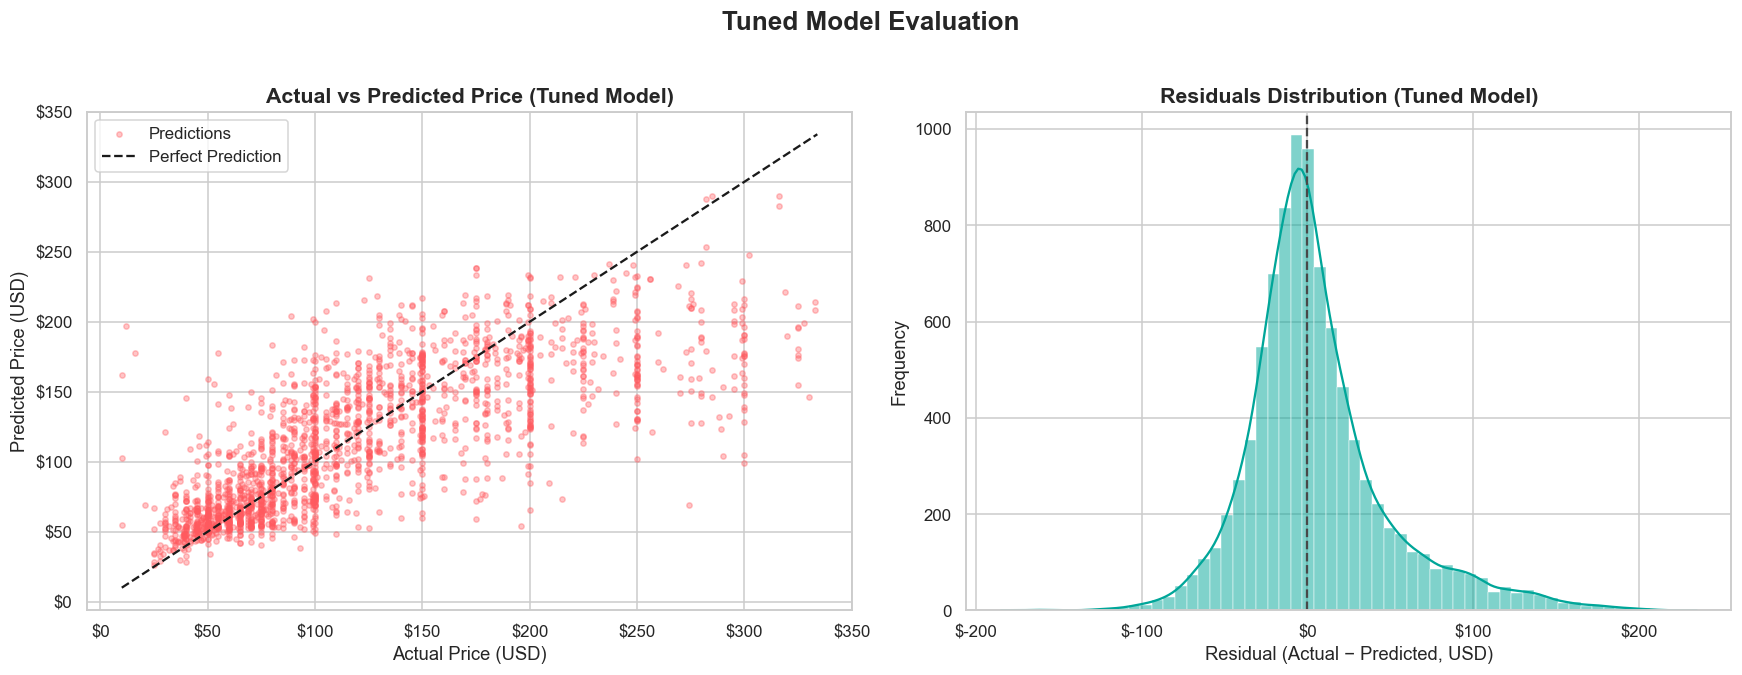

In [94]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# actual vs predicted, scatter
sample_idx = np.random.choice(len(y_true_test), size=min(2000, len(y_true_test)), replace=False)
axes[0].scatter(y_true_test.values[sample_idx], y_pred_tuned[sample_idx],
                alpha=0.35, color=AIRBNB_RED, s=12, label='Predictions')
lims = [min(y_true_test.min(), y_pred_tuned.min()),
        max(y_true_test.max(), y_pred_tuned.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Price (Tuned Model)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Price (USD)'); axes[0].set_ylabel('Predicted Price (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))
axes[0].legend()

# Residuals histogram
residuals = y_true_test.values - y_pred_tuned
sns.histplot(residuals, bins=60, kde=True, color=AIRBNB_TEAL,
             edgecolor='white', linewidth=0.3, ax=axes[1])
axes[1].axvline(0, color='#484848', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Distribution (Tuned Model)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Residual (Actual − Predicted, USD)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))

plt.suptitle('Tuned Model Evaluation', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [95]:
# across all parameter combinations
cv_results = pd.DataFrame(gscv.cv_results_)
cv_results['mean_test_MAE'] = -cv_results['mean_test_score']
cv_results = cv_results.sort_values('mean_test_MAE')

print("Top 5 parameter combinations:")
display(cv_results[['params', 'mean_test_MAE', 'std_test_score']].head(5)
        .rename(columns={'std_test_score': 'std_MAE'})
        .reset_index(drop=True))


Top 5 parameter combinations:


,params,mean_test_MAE,std_MAE
0,"{'learning_rate': 0.05, 'n_estimators': 400, '...",0.257460,0.001246
1,"{'learning_rate': 0.03, 'n_estimators': 400, '...",0.258125,0.001547
2,"{'learning_rate': 0.1, 'n_estimators': 200, 'n...",0.258146,0.001338
3,"{'learning_rate': 0.1, 'n_estimators': 400, 'n...",0.258355,0.001084
4,"{'learning_rate': 0.05, 'n_estimators': 200, '...",0.258506,0.001413


### 9.2 Relative Error Analysis & Bias Check

MAE and RMSE report errors in absolute dollars, which makes it hard to judge whether an error is large or small without knowing the actual price. Relative error expresses the error as a percentage of the actual price, making it comparable across different price levels.

$$\text{Relative Error} = \frac{\hat{y} - y}{y} \times 100\%$$

We keep the sign to detect bias: a positive mean means the model systematically overestimates, if underestimates than it is negative

In [96]:
from scipy import stats

rel_errors = (y_pred_tuned - y_true_test.values) / y_true_test.values * 100
abs_errors = np.abs(y_true_test.values - y_pred_tuned)

mape = np.mean(np.abs(rel_errors))

# D'Agostino-Pearson
_, p_norm = stats.normaltest(abs_errors)

print("=" * 56)
print("RELATIVE ERROR SUMMARY (signed, %)")
print("=" * 56)
print(f"MAPE (Mean Abs %): {mape:.2f}%")
print(f"Mean signed error: {rel_errors.mean():.2f}%  "
      f"({'overestimates' if rel_errors.mean() > 0 else 'underestimates'})")
print(f"Std of signed error: {rel_errors.std():.2f}%")
print(f"Median signed error: {np.median(rel_errors):.2f}%")
print(f"P25 / P75: {np.percentile(rel_errors, 25):.2f}% / {np.percentile(rel_errors, 75):.2f}%")
print()
print("ABSOLUTE ERROR DISTRIBUTION (USD)")
print("=" * 56)
print(f"Mean  +- Std: ${abs_errors.mean():.2f} +- ${abs_errors.std():.2f}")
print(f"Median: ${np.median(abs_errors):.2f}")
print(f"P25 / P75: ${np.percentile(abs_errors, 25):.2f} / ${np.percentile(abs_errors, 75):.2f}")
print(f"P90 / P95: ${np.percentile(abs_errors, 90):.2f} / ${np.percentile(abs_errors, 95):.2f}")
print()
print(f"Normality test p-value: {p_norm}")
if p_norm < 0.05:
    print("Errors are NOT normally distributed. median + percentiles are the correct summary")
else:
    print("Errors are approximately normal. mean +- std is valid")

RELATIVE ERROR SUMMARY (signed, %)
MAPE (Mean Abs %): 27.39%
Mean signed error: 6.51%  (overestimates)
Std of signed error: 46.26%
Median signed error: 1.38%
P25 / P75: -18.32% / 23.80%

ABSOLUTE ERROR DISTRIBUTION (USD)
Mean  +- Std: $30.15 +- $31.23
Median: $20.32
P25 / P75: $8.84 / $39.97
P90 / P95: $70.50 / $96.51

Normality test p-value: 0.0
Errors are NOT normally distributed. median + percentiles are the correct summary


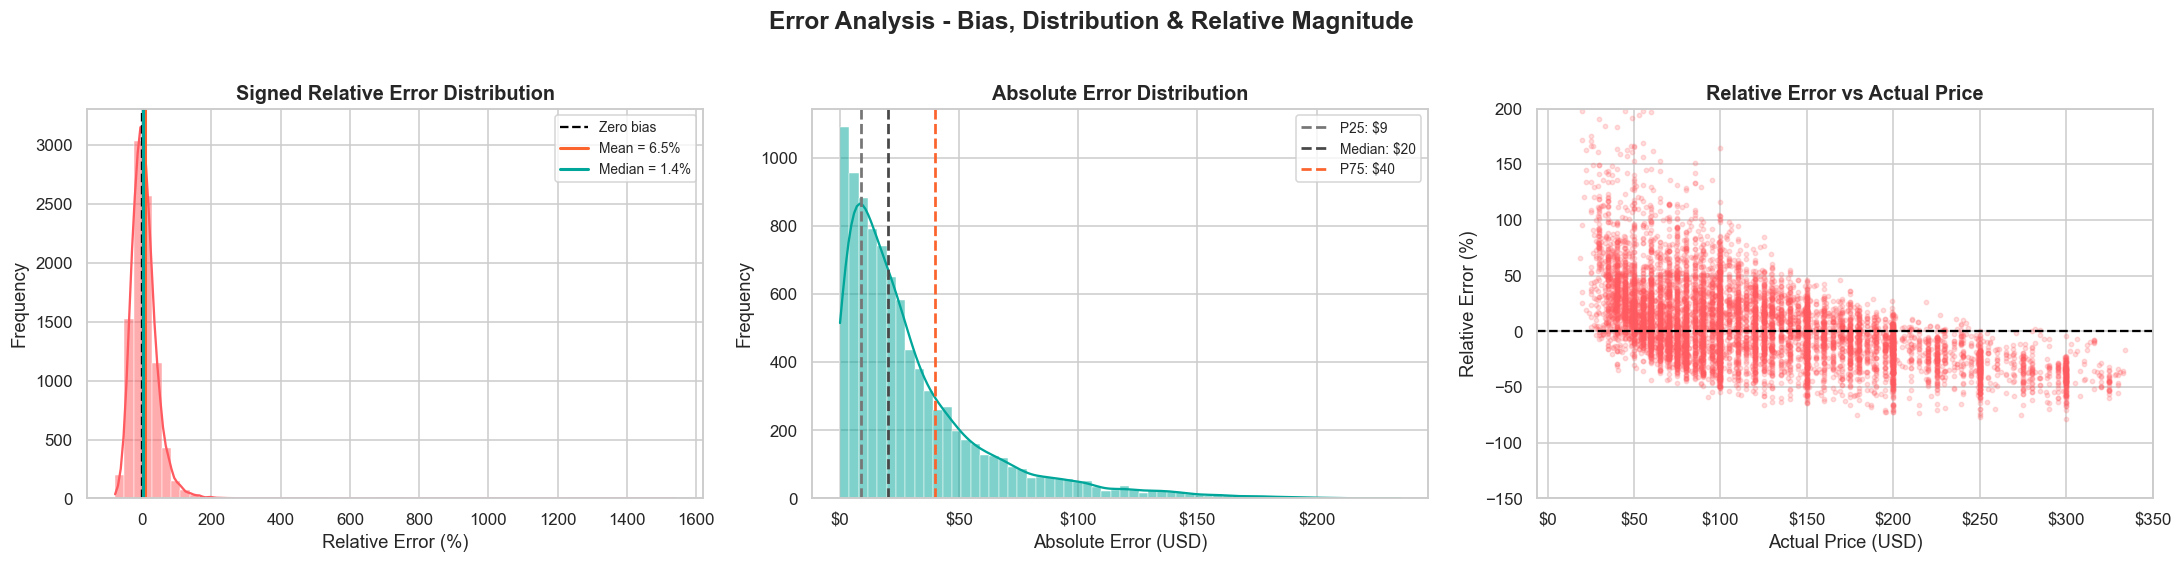

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# relative error distribution
sns.histplot(rel_errors, bins=60, kde=True, color=AIRBNB_RED,
             edgecolor='white', linewidth=0.3, ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', lw=1.5, label='Zero bias')
axes[0].axvline(rel_errors.mean(), color=AIRBNB_ORG, linestyle='-', lw=2,
                label=f'Mean = {rel_errors.mean():.1f}%')
axes[0].axvline(np.median(rel_errors),color=AIRBNB_TEAL, linestyle='-', lw=2,
                label=f'Median = {np.median(rel_errors):.1f}%')
axes[0].set_title('Signed Relative Error Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Relative Error (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Absolute error distribution with percentile lines
sns.histplot(abs_errors, bins=60, kde=True, color=AIRBNB_TEAL,
             edgecolor='white', linewidth=0.3, ax=axes[1])
for pct, lbl, col in [(25, 'P25', '#767676'), (50, 'Median', '#484848'), (75, 'P75', AIRBNB_ORG)]:
    val = np.percentile(abs_errors, pct)
    axes[1].axvline(val, color=col, linestyle='--', lw=1.8, label=f'{lbl}: ${val:.0f}')
axes[1].set_title('Absolute Error Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Absolute Error (USD)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))
axes[1].legend(fontsize=9)

# Relative error vs actual price (bias by price tier)
axes[2].scatter(y_true_test.values, rel_errors, alpha=0.2, color=AIRBNB_RED, s=8)
axes[2].axhline(0, color='black', linestyle='--', lw=1.5)
axes[2].set_title('Relative Error vs Actual Price', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Actual Price (USD)')
axes[2].set_ylabel('Relative Error (%)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x)}'))
axes[2].set_ylim(-150, 200)

plt.suptitle('Error Analysis - Bias, Distribution & Relative Magnitude', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Conclusion

### 10.1 Summary of Results

This project built an end-to-end price prediction pipeline for NYC Airbnb listings using the 2019 Open Data dataset (~48,895 listings). Here is a recap of what was achieved at each stage:

| Stage | Key Action | Outcome |
|---|---|---|
| **Data Cleaning** | Removed duplicates, zero-price rows, IQR-capped outliers | ~6% of rows removed; price range narrowed to realistic $10 - $334 |
| **Feature Engineering** | `dist_to_center` (Haversine), `neighborhood_tier` (median price encoding), `has_reviews` | Substantially improved model signal; `neighborhood_tier` became the #1 predictor (r ≈ 0.50) |
| **EDA** | Borough/room type analysis, review patterns, neighbourhood ranking | Confirmed that geography and room type are multiplicative price drivers |
| **Modelling** | 5 algorithms compared on MAE, RMSE, R^2 | Non-linear ensembles consistently outperformed linear baselines |
| **Tuning** | GridSearchCV with 5-fold CV on LightGBM | MAE reduced to $30.15, R^2 = 0.584 |

Signed errors are centred near zero (median 1.4%) with a long right tail pulling the mean to 6.5%. The model is nearly unbiased but occasionally overestimates. Absolute errors are right-skewed: half of predictions are within $20, 75% within $40, only 10% exceed $70, so median + percentiles is the correct summary (normality test p around 0). Error vs price shows higher relative errors on cheap listings ($50-$100) and tighter spread on expensive ones ($200+), indicating the model is less reliable in the budget segment

### 10.2 Key Findings

1. Manhattan median prices are roughly twice Brooklyn's and 3–4 times the outer boroughs. The engineered `neighborhood_tier` feature became the single most important predictor
2. Entire homes command a consistent approximately twice premium over private rooms across all five boroughs. This "privacy premium" is multiplicative with location, not additive
3. All numerical features individually exhibit weak linear correlation with price (|r| < 0.2 for raw features). This explains why Linear and Ridge Regression are substantially outperformed by tree-based ensembles
4. Unreviewed listings carry a slightly higher median price, review accumulation correlates with price normalisation
5. Listings with 100+ reviews skew toward the $50-$100 range, confirming that price competitiveness drives booking frequency